# Ejemplo Regresión lineal

## 1. Importar librerías

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Crear datos sintéticos

In [2]:
# Queremos predecir "ventas" a partir de "inversión en publicidad"
np.random.seed(0)

X = 2.5 * np.random.rand(100, 1)      # inversión (0 a 2.5)
Y = (12 + (2.8 * X)) + np.random.randn(100, 1)  # ventas con ruido

# Convertir a DataFrame para visualización
df = pd.DataFrame({'Inversion_Publicidad': X.flatten(),
                   'Ventas': Y.flatten()})
df.head()

,Inversion_Publicidad,Ventas
0,1.372034,14.676545
1,1.787973,17.907152
2,1.506908,16.685006
3,1.362208,14.277939
4,1.059137,16.453836


## 3. Gráfica inicial

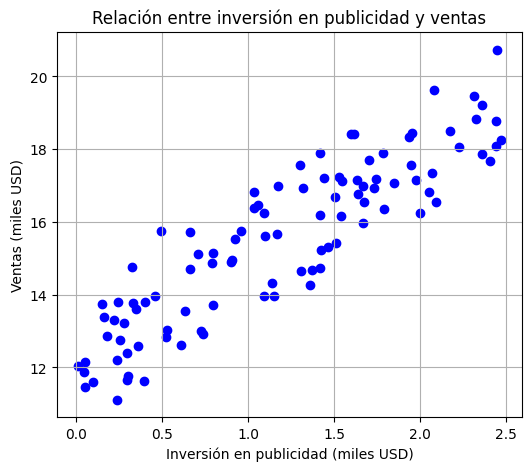

In [3]:
plt.figure(figsize=(6,5))
plt.scatter(df['Inversion_Publicidad'], df['Ventas'], color="blue")
plt.title("Relación entre inversión en publicidad y ventas")
plt.xlabel("Inversión en publicidad (miles USD)")
plt.ylabel("Ventas (miles USD)")
plt.grid(True)
plt.show()

## 4. Dividir datos en entrenamiento y prueba
**train_test_split** es una función de **sklearn.model_selection** que divide (split) tus datos en conjuntos de entrenamiento y prueba (test).\
Recibe tus entradas (X) y etiquetas/targets (Y) y devuelve cuatro objetos: los pares de entrada/target para entrenamiento y prueba.\

**X_train** — las filas de X que irán a entrenamiento\
**X_test** — las filas de X que irán a prueba\
**Y_train** — los targets correspondientes a X_train\
**Y_test** — los targets correspondientes a X_test\
\
**test_size=0.2** (0.2 = 20%) Indica el porcentaje de muestras para el conjunto de prueba.\
Con 100 muestras, **test_size=0.2** hará que X_test tenga ~20 muestras y X_train ~80.\
Otra opcion es indicar **test_size=20**, serían 20 muestras también.\
\
**random_state=42** es la semilla del generador aleatorio para la selección aleatoria de muestras.\
Si se pone un entero fijo (ej. 42), la partición será reproducible: ejecutar el mismo código varias veces da la misma división.\
Si se omite o se indica None, cada ejecución produce una partición diferente.\
\
**Nota:** Por defecto **shuffle=True**, así que se barajan las filas antes de partir; random_state controla ese barajado. Si **shuffle=False**, los datos se parten sin mezclar (útil cuando el orden tiene sentido temporal — por ejemplo, series temporales no se deben mezclar).

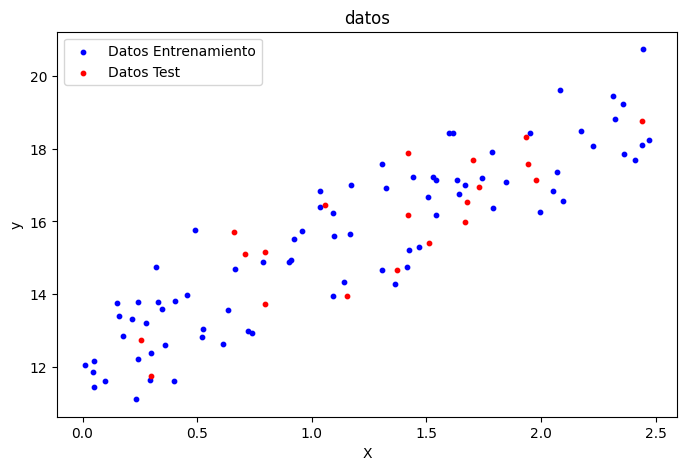

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


#Se grafican los datos
X_grid = np.linspace(-3, 3, 500).reshape(-1, 1)
y_grid_pred = modelo.predict(X_grid)
plt.figure(figsize=(8, 5))
plt.scatter(X_train, Y_train, label="Datos Entrenamiento", s=10, color="blue")
plt.scatter(X_test, Y_test, label="Datos Test", s=10, color="red")
plt.title("datos")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## 5. Crear y entrenar el modelo
**LinearRegression** es una clase de scikit-learn que implementa un modelo de regresión lineal.\
**modelo = LinearRegression()** Crea un objeto modelo vacío, es decir, un modelo sin entrenar.
En ese momento, no tiene ni pendiente ni intercpetación calculadas.\
**modelo.fit(X_train, y_train)** entrena el modelo usando los datos de entrenamiento.
Internamente, scikit-learn:\
Calcula la línea recta que mejor se ajusta a los puntos.\
Encuentra los valores óptimos de:\
**coef_** → pendientes (puede haber varias si tienes múltiples columnas)\
**intercept_** → intercepto (b₀)\
El modelo aprende la relación matemática entre X e Y.\

In [11]:
modelo = LinearRegression()
modelo.fit(X_train, Y_train)

print("Coeficiente (pendiente):", modelo.coef_[0][0])
print("Intercepción:", modelo.intercept_[0])


Coeficiente (pendiente): 2.7922072808039125
Intercepción: 12.206340188711435


## 6. Predecir con los datos de prueba
Esta instrucción usa el modelo ya entrenado (modelo) para predecir la variable objetivo (y) utilizando los datos de prueba (X_test).\
**modelo.predict(...)** toma un conjunto de entradas (características) y produce valores predichos, solo funciona después de haber implementado **modelo.fit(X_train, y_train)**, es decir, después de entrenar el modelo.\
**X_test** Son los datos que NO se usaron para entrenar el modelo, se utilizan para evaluar qué tan bien generaliza el modelo.\
El resultado **y_pred** es un arreglo de valores predichos por el modelo lineal. Cada valor corresponde a la predicción de la variable objetivo para cada registro en **X_test**.

In [19]:
Y_pred = modelo.predict(X_test)

## 7. Métricas de evaluación
**mean_absolute_error(y_test, y_pred)** El error absoluto medio mide cuánto se equivoca el modelo en promedio, sin importar si la predicción quedó por arriba o por abajo.\
mae=(1/n)​∑(∣yreal​−ypred​∣) \
**mse = mean_squared_error(y_test, y_pred)** El error cuadrático medio mide el error promedio, pero eleva al cuadrado las diferencias.\
mse=(1/n)​∑((yreal​−ypred​)^2) \
**rmse = np.sqrt(mse)** Es la raíz cuadrada del mse.\
**r2 = r2_score(y_test, y_pred)** Mide qué porcentaje de la variación de los datos puede explicar el modelo.\
SST=∑​((yreal​−yprom​)^2)\
SSE=∑​((yreal​−ypred​)^2)\
R²=1- (SSE)/(SST)\
**Interpretación del R²:**\
R²=1.0 → el modelo explica el 100% de la variación (perfecto).\
R²=0 → el modelo no explica nada (predice lo mismo que un promedio).\
R²< 0 → el modelo es peor que adivinar usando el promedio.\
R² ≥ 0.75 → Muy buen modelo (explica la mayor parte de la variación).\
0.50 ≤ R² < 0.75 → Modelo aceptable o bueno, dependiendo del contexto.\
R² < 0.50 → El modelo explica poco; podría mejorarse.

In [20]:
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print("\n--- Métricas del modelo ---")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)


--- Métricas del modelo ---
MAE: 0.8014554834253336
MSE: 0.9177532469714293
RMSE: 0.9579943877557057
R²: 0.7219575249254884


## 8. Gráfico de regresión final

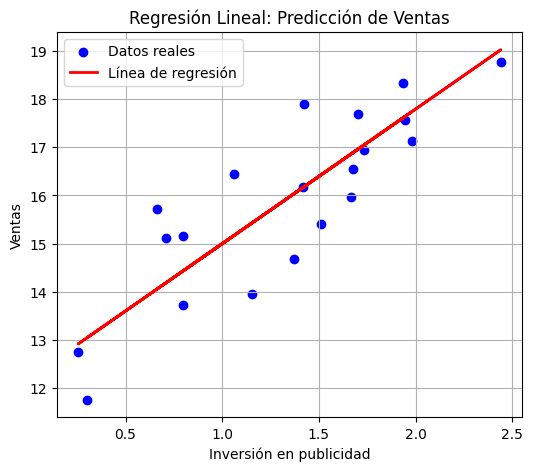

In [21]:
plt.figure(figsize=(6,5))
plt.scatter(X_test, Y_test, color='blue', label='Datos reales')
plt.plot(X_test, Y_pred, color='red', linewidth=2, label='Línea de regresión')
plt.xlabel("Inversión en publicidad")
plt.ylabel("Ventas")
plt.title("Regresión Lineal: Predicción de Ventas")
plt.legend()
plt.grid(True)
plt.show()